# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2782s 16us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

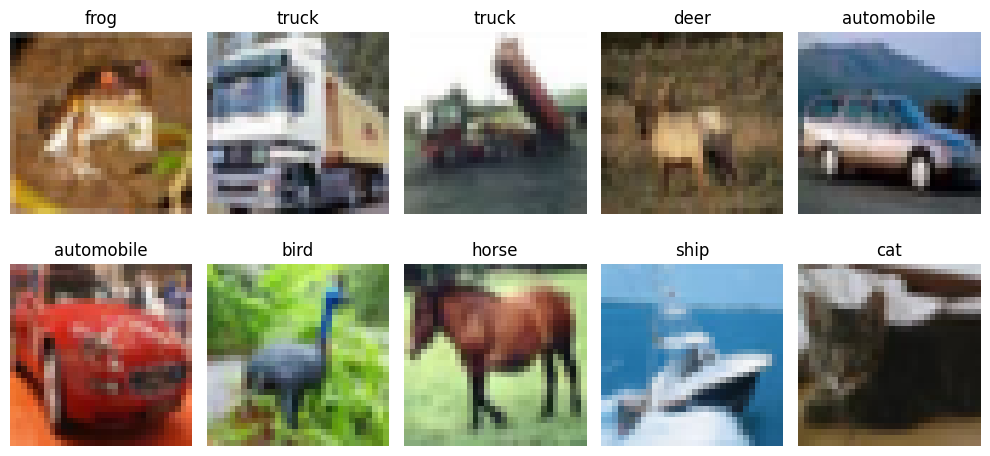

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2670 - loss: 2.0045 - val_accuracy: 0.3250 - val_loss: 1.8605
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3153 - loss: 1.8715 - val_accuracy: 0.3478 - val_loss: 1.8066
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3363 - loss: 1.8202 - val_accuracy: 0.3814 - val_loss: 1.7560
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3508 - loss: 1.7843 - val_accuracy: 0.3850 - val_loss: 1.7292
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3603 - loss: 1.7606 - val_accuracy: 0.4042 - val_loss: 1.7099
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3656 - loss: 1.7454 - val_accuracy: 0.3916 - val_loss: 1.7361
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3752 - loss: 1.7246 - val_accuracy: 0.4006 - val_loss: 1.7131
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3841 - loss: 1.7014 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4341 - loss: 1.6159
ANN Test Accuracy: 0.4341000020503998


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4824 - loss: 1.4560 - val_accuracy: 0.5528 - val_loss: 1.2916
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6219 - loss: 1.0854 - val_accuracy: 0.6362 - val_loss: 1.0458
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6797 - loss: 0.9174 - val_accuracy: 0.6674 - val_loss: 0.9755
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7220 - loss: 0.8019 - val_accuracy: 0.6742 - val_loss: 0.9600
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7514 - loss: 0.7104 - val_accuracy: 0.6838 - val_loss: 0.9177
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7739 - loss: 0.6435 - val_accuracy: 0.7220 - val_loss: 0.8377
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8002 - loss: 0.5691 - val_accuracy: 0.7266 - val_loss: 0.8495
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8172 - loss: 0.5171 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7204 - loss: 1.0065
CNN Test Accuracy: 0.7203999757766724


## 📈 Compare Learning Curves

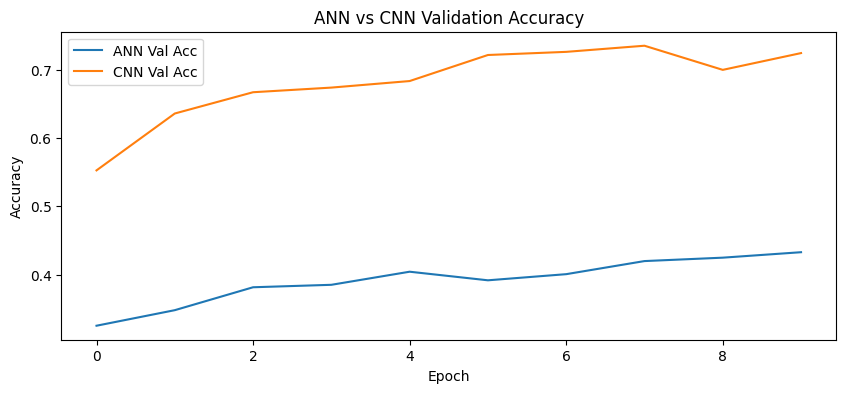

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4341
1,CNN,0.7204


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

**Task 1: Increase ANN Layers**

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

ann_model_deep = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ann_model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann_deep = ann_model_deep.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_data=(x_test_norm,y_test)
)

ann_deep_loss, ann_deep_acc = ann_model_deep.evaluate(x_test_norm,y_test)

print("Deep ANN Accuracy:", ann_deep_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3060 - loss: 1.8957 - val_accuracy: 0.3806 - val_loss: 1.7182
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3853 - loss: 1.7095 - val_accuracy: 0.4074 - val_loss: 1.6459
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4164 - loss: 1.6203 - val_accuracy: 0.4308 - val_loss: 1.5974
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4426 - loss: 1.5578 - val_accuracy: 0.4494 - val_loss: 1.5507
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4524 - loss: 1.5211 - val_accuracy: 0.4634 - val_loss: 1.5137
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4690 - loss: 1.4799 - val_accuracy: 0.4432 - val_loss: 1.5477
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4811 - loss: 1.4529 - val_accuracy: 0.4769 - val_loss: 1.4781
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4900 - loss: 1.4234 

### Result

The deeper ANN achieved better accuracy than the basic ANN because it learned more complex representations.

However, CNN still performs better because convolution layers preserve image features and spatial relationships.

**Task 2: Increase CNN Filters (32→64→128)**

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization

cnn_filters = Sequential([

    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(10,activation='softmax')

])

cnn_filters.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_filters = cnn_filters.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_data=(x_test_norm,y_test)
)

cnn_filter_loss, cnn_filter_acc = cnn_filters.evaluate(x_test_norm,y_test)
print("CNN Filter Accuracy:", cnn_filter_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.5584 - loss: 1.2492 - val_accuracy: 0.6284 - val_loss: 1.0656
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7001 - loss: 0.8523 - val_accuracy: 0.6587 - val_loss: 0.9898
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7580 - loss: 0.6944 - val_accuracy: 0.6909 - val_loss: 0.8970
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7981 - loss: 0.5794 - val_accuracy: 0.7201 - val_loss: 0.8262
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8310 - loss: 0.4854 - val_accuracy: 0.7242 - val_loss: 0.8821
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8630 - loss: 0.3935 - val_accuracy: 0.7100 - val_loss: 0.9855
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8855 - loss: 0.3232 - val_accuracy: 0.7282 - val_loss: 0.9579
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9052 - loss: 0.2677

**Task 3: Increase Epochs to 20**

In [16]:
history20 = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_data=(x_test_norm,y_test)
)

cnn20_loss, cnn20_acc = cnn_model.evaluate(x_test_norm,y_test)

print("CNN Accuracy after 20 Epochs:", cnn20_acc)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7875 - loss: 0.6208 - val_accuracy: 0.6970 - val_loss: 0.9924
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8142 - loss: 0.5291 - val_accuracy: 0.7102 - val_loss: 0.9311
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8319 - loss: 0.4772 - val_accuracy: 0.7286 - val_loss: 0.9351
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8456 - loss: 0.4402 - val_accuracy: 0.7195 - val_loss: 0.9732
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8571 - loss: 0.4104 - val_accuracy: 0.7178 - val_loss: 1.0354
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8650 - loss: 0.3780 - val_accuracy: 0.7182 - val_loss: 1.0578
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8727 - loss: 0.3598 - val_accuracy: 0.7240 - val_loss: 0.9602
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8860 - loss: 0.3242 -

### Result

Training for more epochs generally improves accuracy because the model has more opportunities to optimize its weights.

However, too many epochs can cause overfitting.In the above case increasing epochs led to decreased accuracy.

**Task 4: Add EarlyStopping**

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_es = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_data=(x_test_norm,y_test),
    callbacks=[early_stop]
)

cnn_es_loss, cnn_es_acc = cnn_model.evaluate(x_test_norm,y_test)

print("CNN Accuracy with EarlyStopping:", cnn_es_acc)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9336 - loss: 0.1934 - val_accuracy: 0.7313 - val_loss: 1.2957
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9366 - loss: 0.1824 - val_accuracy: 0.7419 - val_loss: 1.2477
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9368 - loss: 0.1792 - val_accuracy: 0.7362 - val_loss: 1.2814
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9378 - loss: 0.1779 - val_accuracy: 0.7475 - val_loss: 1.3736
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9426 - loss: 0.1642 - val_accuracy: 0.7343 - val_loss: 1.4366
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7419 - loss: 1.2477
CNN Accuracy with EarlyStopping: 0.7419000267982483


### Result

EarlyStopping automatically stopped training when validation loss stopped improving.

This reduced overfitting and restored the best model weights.

**Task 5: Data Augmentation Training**

In [20]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense

augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

augmented_model = Sequential([

    augmentation,

    Conv2D(32,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),

    Dense(10,activation='softmax')

])

augmented_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_aug = augmented_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_data=(x_test_norm,y_test)
)

aug_loss, aug_acc = augmented_model.evaluate(x_test_norm,y_test)

print("Augmented CNN Accuracy:", aug_acc)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.4742 - loss: 1.4747 - val_accuracy: 0.5134 - val_loss: 1.4052
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5855 - loss: 1.1685 - val_accuracy: 0.6208 - val_loss: 1.0620
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6367 - loss: 1.0321 - val_accuracy: 0.6473 - val_loss: 1.0266
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6603 - loss: 0.9658 - val_accuracy: 0.6878 - val_loss: 0.9195
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6870 - loss: 0.8979 - val_accuracy: 0.6971 - val_loss: 0.8738
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7029 - loss: 0.8546 - val_accuracy: 0.6899 - val_loss: 0.9429
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7137 - loss: 0.8197 - val_accuracy: 0.6833 - val_loss: 0.9392
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7281 -

### Result

Data augmentation generated new image variations during training.

This improved model robustness and reduced overfitting, leading to better generalization on unseen images.

#  Final Comparison of All Models

The table below compares the performance of all implemented models.

In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Basic ANN",
        "Deep ANN",
        "Basic CNN",
        "CNN (32-64-128)",
        "CNN (20 Epochs)",
        "CNN + EarlyStopping",
        "CNN + Data Augmentation"
    ],
    "Accuracy": [
        ann_test_acc,
        ann_deep_acc,
        cnn_test_acc,
        cnn_filter_acc,
        cnn20_acc,
        cnn_es_acc,
        aug_acc
    ]
})

comparison

,Model,Accuracy
0,Basic ANN,0.4341
1,Deep ANN,0.4879
2,Basic CNN,0.7204
3,CNN (32-64-128),0.6976
4,CNN (20 Epochs),0.7029
5,CNN + EarlyStopping,0.7419
6,CNN + Data Augmentation,0.7144


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**